### Library

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import learning_curve

In [4]:
df = pd.read_csv("ev_battery_failure_dataset.csv")
df.head(3)

,vehicle_id,vehicle_brand,vehicle_model,vehicle_type,manufacturing_year,battery_manufacturer,battery_chemistry,battery_capacity_kwh,drive_type,odometer_km,...,sensor_fault_count,BMS_warning_count,abnormal_voltage_events,battery_stress_index,aging_score,thermal_health_score,charging_quality_score,driving_stress_score,predicted_remaining_life_cycles,battery_failure
0,EV100000,Nissan,Leaf,SUV,2019.0,CATL,LMO,82.54,RWD,98163.0,...,2.0,3.0,0.0,0.0,53.5,66.0,65.2,0.0,401.0,0
1,EV100001,Audi,e-tron,Sedan,2018.0,Samsung SDI,NaN,64.17,AWD,113600.0,...,0.0,3.0,0.0,51.0,38.8,67.8,46.3,40.9,1094.0,0
2,EV100002,Toyota,bZ4X,Van,2018.0,Guoxuan,NMC,90.92,RWD,242253.0,...,4.0,1.0,0.0,36.2,66.1,48.6,0.0,6.5,645.0,0


## Check the Summary of The Dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 70 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   vehicle_id                       200000 non-null  object 
 1   vehicle_brand                    193564 non-null  object 
 2   vehicle_model                    191796 non-null  object 
 3   vehicle_type                     193568 non-null  object 
 4   manufacturing_year               190171 non-null  float64
 5   battery_manufacturer             193812 non-null  object 
 6   battery_chemistry                192786 non-null  object 
 7   battery_capacity_kwh             193097 non-null  float64
 8   drive_type                       192732 non-null  object 
 9   odometer_km                      191334 non-null  float64
 10  vehicle_age_years                192317 non-null  float64
 11  fleet_or_private                 191050 non-null  object 
 12  ba

In [6]:
for col in df.columns:
    unique_vals = df[col].nunique(dropna=False)
    if unique_vals <= 50:
        print(f"--- {col} ({unique_vals} unique values) ---")
        print(df[col].value_counts(dropna=False))
        print("\n")

--- vehicle_brand (21 unique values) ---
vehicle_brand
Tesla         21840
BYD           20187
Volkswagen    14629
Hyundai       12940
GM            11087
Ford          10924
Kia           10780
Mercedes       9193
Nissan         9108
BMW            9063
Toyota         9039
Tata           7372
Audi           7287
Volvo          7276
Renault        7268
NaN            6436
MG             5489
Mahindra       5464
Rivian         5452
Honda          5417
Lucid          3749
Name: count, dtype: int64


--- vehicle_type (7 unique values) ---
vehicle_type
SUV          58202
Sedan        42309
Hatchback    34857
Crossover    31057
Truck        15618
Van          11525
NaN           6432
Name: count, dtype: int64


--- manufacturing_year (11 unique values) ---
manufacturing_year
2021.0    19245
2015.0    19166
2023.0    19043
2022.0    19040
2019.0    18999
2024.0    18980
2018.0    18966
2016.0    18925
2017.0    18915
2020.0    18892
NaN        9829
Name: count, dtype: int64


--- battery_man

In [7]:
pd.set_option('display.max_rows', None)
(df.isna().sum() / len(df)) * 100

vehicle_id                         0.0000
vehicle_brand                      3.2180
vehicle_model                      4.1020
vehicle_type                       3.2160
manufacturing_year                 4.9145
battery_manufacturer               3.0940
battery_chemistry                  3.6070
battery_capacity_kwh               3.4515
drive_type                         3.6340
odometer_km                        4.3330
vehicle_age_years                  3.8415
fleet_or_private                   4.4750
battery_serial                     0.0000
cycle_count                        3.8260
battery_health_percent             4.4910
state_of_charge                    4.8180
depth_of_discharge                 4.1565
state_of_health                    4.7825
cell_voltage_avg                   4.6990
cell_voltage_std                   4.2815
pack_voltage                       3.0875
cell_temperature_avg               3.8415
cell_temperature_max               4.7250
internal_resistance               

In [8]:
#Check
total_baris_awal = len(df)
total_baris_setelah_drop = len(df.dropna())
persentase_hilang = ((total_baris_awal - total_baris_setelah_drop) / total_baris_awal) * 100

print("Total baris awal: ", total_baris_awal)
print("Sisa baris jika di-drop semua: ", total_baris_setelah_drop)
print("Persentase data yang terbuang: ", persentase_hilang, "%")

Total baris awal:  200000
Sisa baris jika di-drop semua:  13361
Persentase data yang terbuang:  93.3195 %


In [9]:
catagorical = df.select_dtypes(include='object').columns
for col in catagorical:
    df[col] = df[col].fillna('Unknown')

### Distribution of Battery Failure

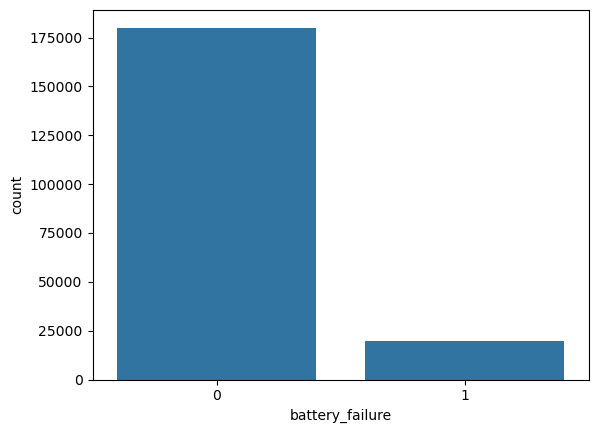

In [10]:
sns.countplot(x=df['battery_failure'])
plt.show()

### Heatmap

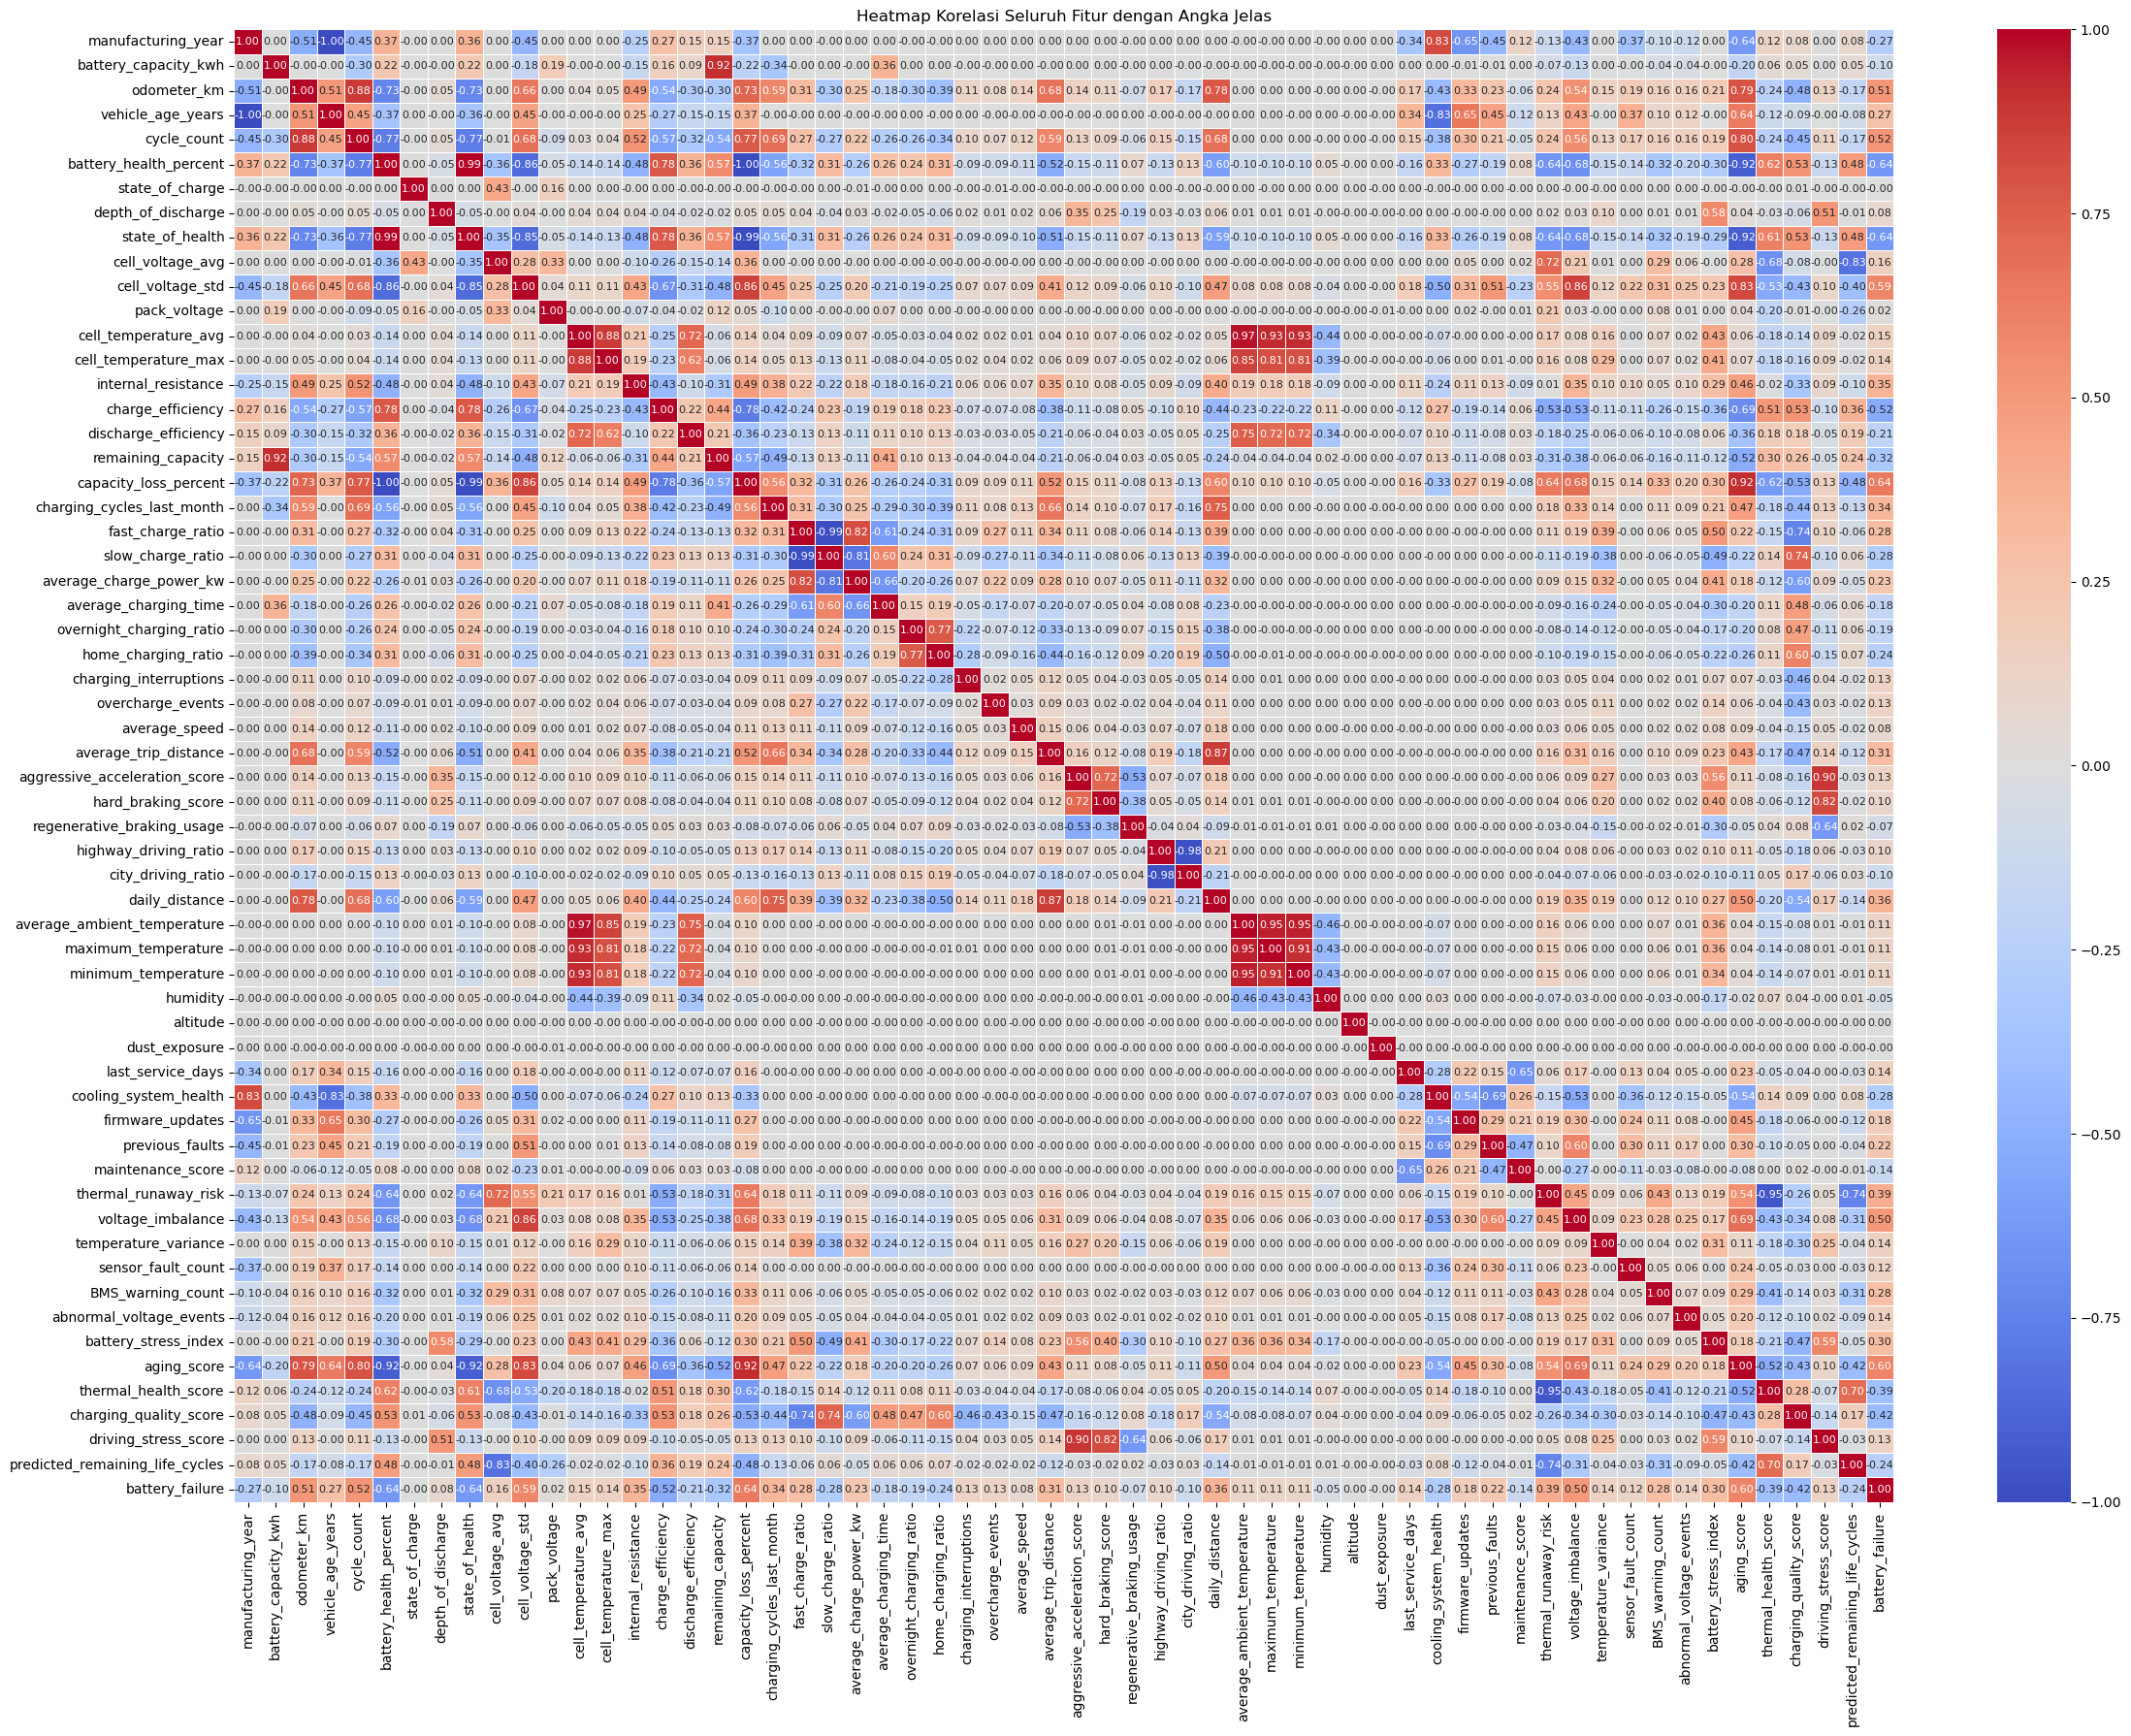

In [11]:
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(24, 18))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot_kws={"size": 8}, 
    linewidths=0.5    
)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.title('Heatmap Korelasi Seluruh Fitur dengan Angka Jelas')
plt.tight_layout()
plt.show()

### Outlier Check

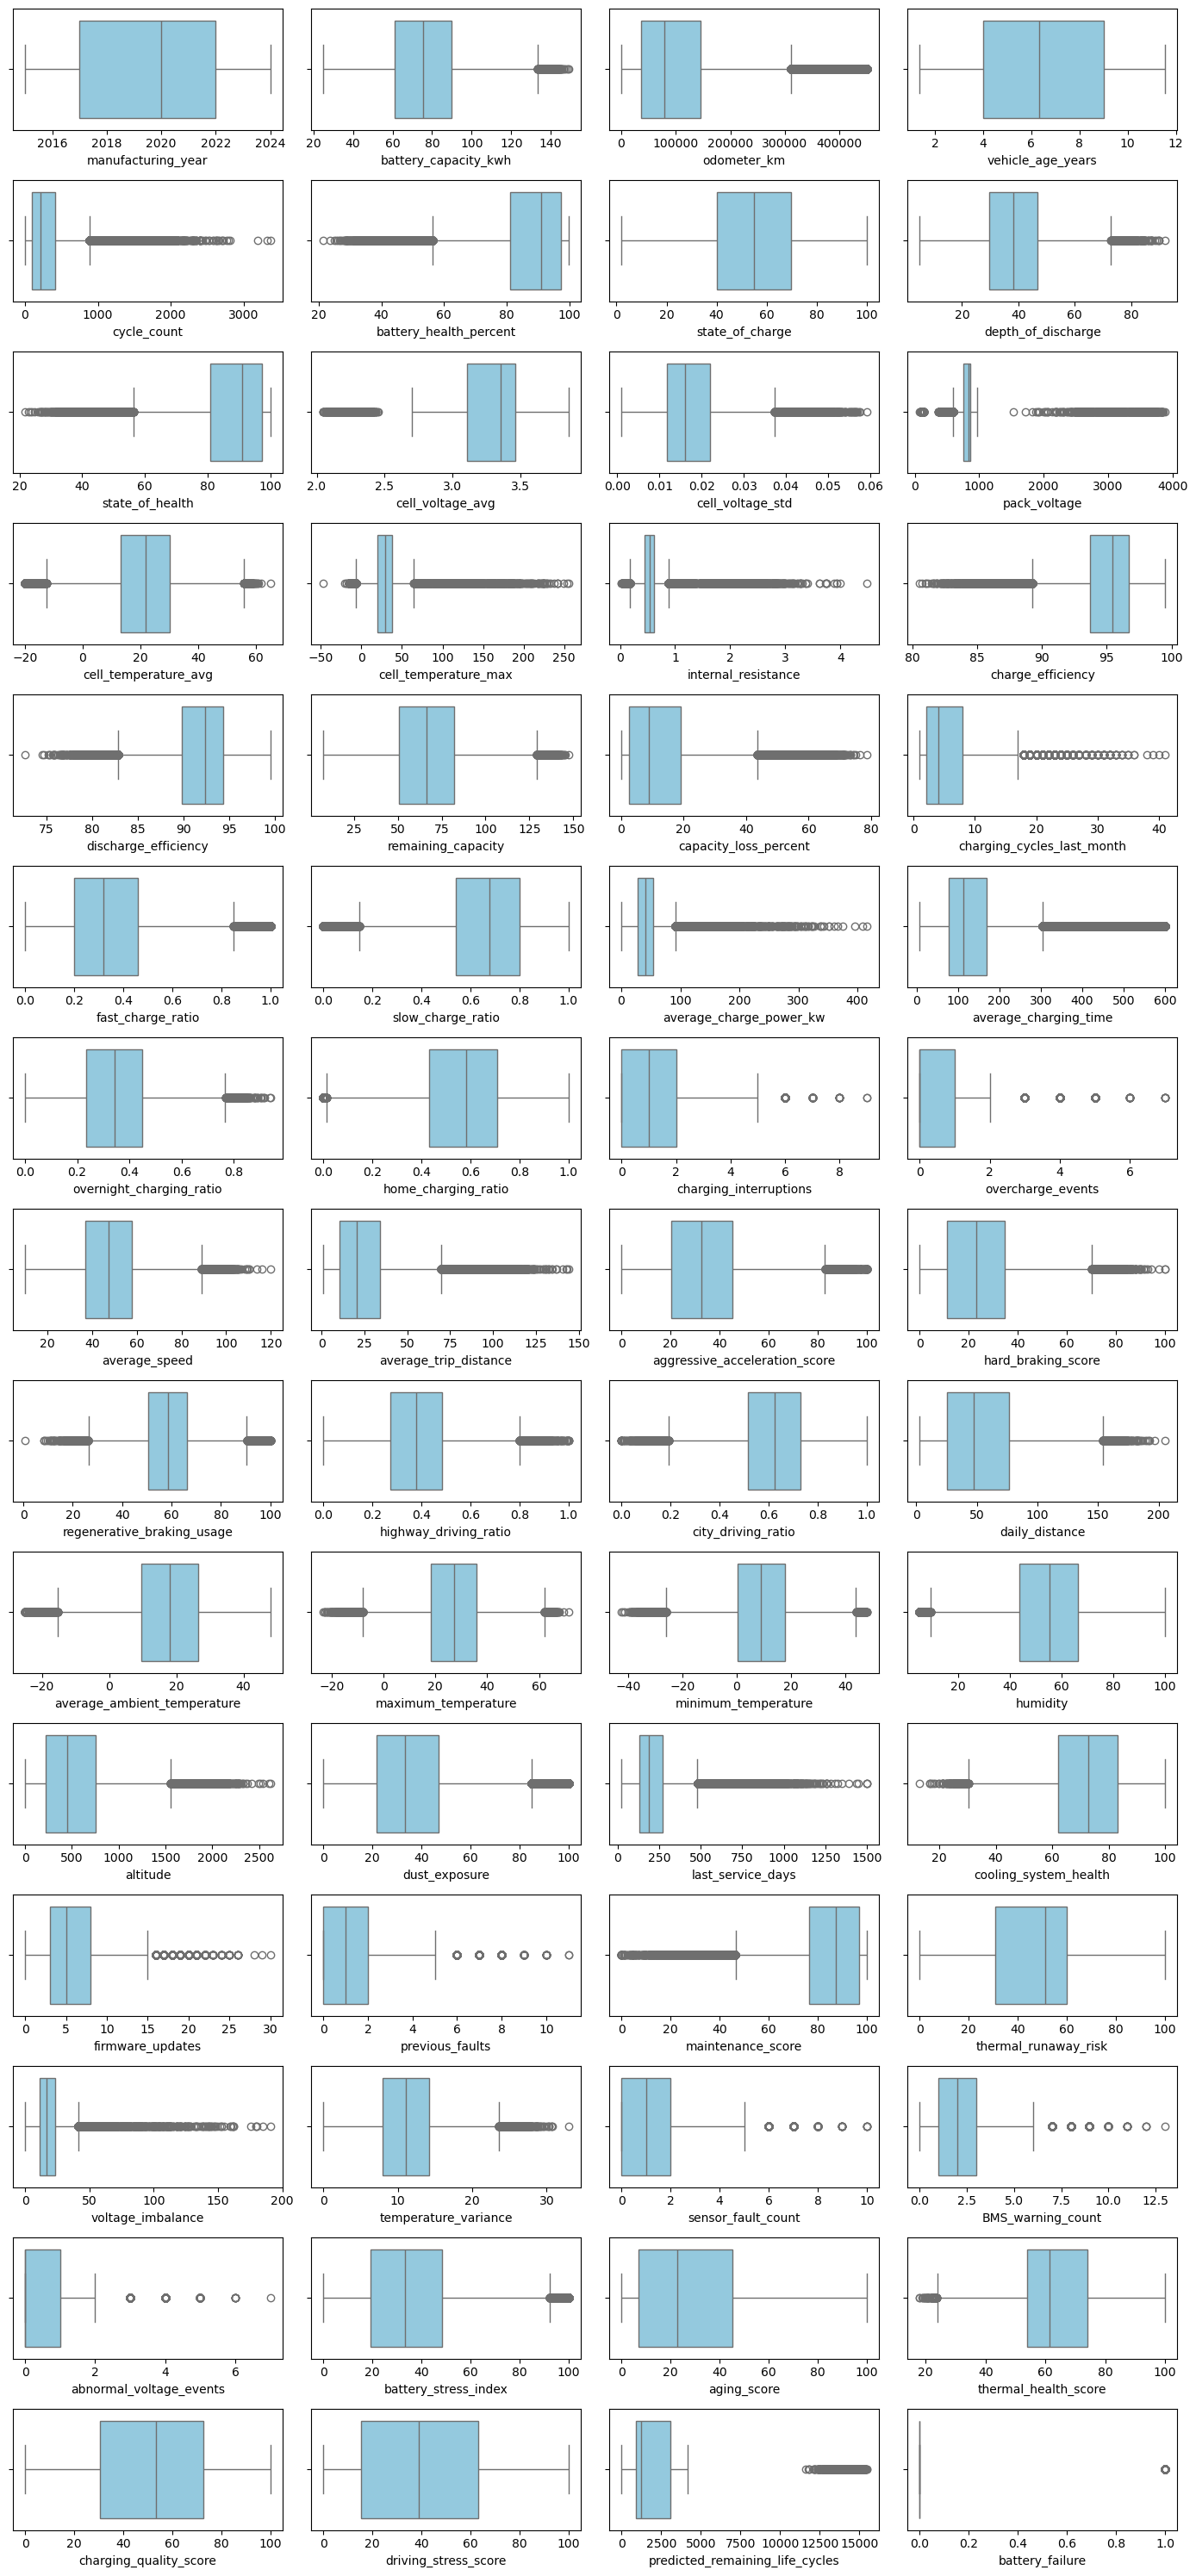

In [12]:
Numerical = df.select_dtypes(include=['number']).columns
jumlah_kolom = len(Numerical)
kolom_grid = 4
baris_grid = math.ceil(jumlah_kolom / kolom_grid)

plt.figure(figsize=(14, 2 * baris_grid))

for i, col in enumerate(Numerical, 1):
    plt.subplot(baris_grid, kolom_grid, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.xlabel(col, fontsize=10)

plt.tight_layout()
plt.show()

## Feature Engineering

In [13]:
df['degradation_rate'] = df['capacity_loss_percent'] / df['cycle_count']
df['thermal_charging_stress'] = df['fast_charge_ratio'] * df['cell_temperature_max']

In [14]:
del_col = ['vehicle_id','battery_serial', 'manufacturing_year', 'slow_charge_ratio', 'highway_driving_ratio', 'capacity_loss_percent', 'maximum_temperature', 'minimum_temperature', 'cell_temperature_max']
df = df.drop(columns=del_col)

## Split Data

In [15]:
x = df.drop(columns=['battery_failure'])
y = df['battery_failure']

#Split Data
x_train, x_test, y_train, y_test, = train_test_split(x,y, test_size = 0.2, random_state = 42, stratify= y)

In [16]:
print("x_train size: ", x_train.shape[0])
print("x_test size: ", x_test.shape[0])
print("y_train size: ", y_train.shape[0])
print("y_test size: ", y_test.shape[0])

x_train size:  160000
x_test size:  40000
y_train size:  160000
y_test size:  40000


In [17]:
for col in df.columns:
    unique_vals = df[col].nunique(dropna=False)
    if unique_vals <= 50:
        print(f"--- {col} ({unique_vals} unique values) ---")
        print(df[col].value_counts(dropna=False))
        print("\n")

--- vehicle_brand (21 unique values) ---
vehicle_brand
Tesla         21840
BYD           20187
Volkswagen    14629
Hyundai       12940
GM            11087
Ford          10924
Kia           10780
Mercedes       9193
Nissan         9108
BMW            9063
Toyota         9039
Tata           7372
Audi           7287
Volvo          7276
Renault        7268
Unknown        6436
MG             5489
Mahindra       5464
Rivian         5452
Honda          5417
Lucid          3749
Name: count, dtype: int64


--- vehicle_type (7 unique values) ---
vehicle_type
SUV          58202
Sedan        42309
Hatchback    34857
Crossover    31057
Truck        15618
Van          11525
Unknown       6432
Name: count, dtype: int64


--- battery_manufacturer (10 unique values) ---
battery_manufacturer
CATL                  42675
LG Energy Solution    31005
Panasonic             23385
BYD Battery           23044
Samsung SDI           19317
SK On                 17736
Envision AESC         15430
Northvolt          

In [18]:
df['vehicle_brand'].unique()

array(['Nissan', 'Audi', 'Toyota', 'Volkswagen', 'Tesla', 'MG', 'BYD',
       'BMW', 'Mahindra', 'Volvo', 'Renault', 'Hyundai', 'GM', 'Lucid',
       'Tata', 'Honda', 'Kia', 'Ford', 'Unknown', 'Mercedes', 'Rivian'],
      dtype=object)

In [28]:
no_outlier = [
    'vehicle_age_years', 'state_of_charge', 
    'thermal_runaway_risk', 'driving_stress_score'
]

num_outlier = [
    'battery_capacity_kwh', 'odometer_km', 'cycle_count', 
    'battery_health_percent', 'depth_of_discharge', 'state_of_health', 
    'cell_voltage_avg', 'cell_voltage_std', 'pack_voltage', 
    'cell_temperature_avg','internal_resistance', 
    'charge_efficiency', 'discharge_efficiency', 'remaining_capacity', 'charging_cycles_last_month', 'fast_charge_ratio', 
    'average_charge_power_kw', 'average_charging_time', 
    'overnight_charging_ratio', 'home_charging_ratio', 'charging_interruptions', 
    'overcharge_events', 'average_speed', 'average_trip_distance', 
    'aggressive_acceleration_score', 'hard_braking_score', 'regenerative_braking_usage', 
    'city_driving_ratio', 'daily_distance', 
    'average_ambient_temperature', 
    'humidity', 'altitude', 'dust_exposure', 'last_service_days', 
    'cooling_system_health', 'firmware_updates', 'previous_faults', 
    'maintenance_score', 'voltage_imbalance', 'temperature_variance', 
    'sensor_fault_count', 'BMS_warning_count', 'abnormal_voltage_events', 
    'battery_stress_index', 'aging_score', 'thermal_health_score', 
    'charging_quality_score', 'predicted_remaining_life_cycles', 
    'degradation_rate', 'thermal_charging_stress'
]

categorical = [
    'vehicle_brand', 'vehicle_model', 'vehicle_type', 
    'battery_manufacturer', 'battery_chemistry', 'drive_type', 
    'fleet_or_private', 'terrain_type'
]


In [29]:
outlier_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

no_outlier_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

categorical_pipeline = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('outlier', outlier_pipeline, num_outlier),
    ('no_outlier', no_outlier_pipeline, no_outlier),
    ('cat', categorical_pipeline, categorical)
])

## Class Weighting & Modelling

In [30]:
ratio = sum(y_train == 0) / sum(y_train == 1)

In [41]:
Models = {
    'Decision Tree': {
        'model': DecisionTreeClassifier(class_weight='balanced', random_state=42),
        'params': {
            'classifier__max_depth': [3, 5, 7],
            'classifier__min_samples_split': [10, 20, 50],
            'classifier__min_samples_leaf': [5, 10, 20]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(class_weight='balanced', random_state=42),
        'params': {
            'classifier__n_estimators': [50, 100],
            'classifier__max_depth': [3, 5, 7],
            'classifier__min_samples_leaf': [5, 10]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss'),
        'params': {
            'classifier__n_estimators': [50, 100],
            'classifier__learning_rate': [0.01, 0.05, 0.1],
            'classifier__max_depth': [2, 3, 4],
            'classifier__subsample': [0.7, 0.8]
        }
    },
    'LightGBM': {
        'model': LGBMClassifier(class_weight='balanced', random_state=42),
        'params': {
            'classifier__n_estimators': [50, 100],
            'classifier__learning_rate': [0.01, 0.05, 0.1],
            'classifier__max_depth': [2, 3, 4],
            'classifier__subsample': [0.7, 0.8]
        }
    }
}

In [38]:
def class_report(y_true, y_pred, model_name):
    print(f"Classification Report untuk {model_name}:")
    print(classification_report(y_true, y_pred))

In [39]:
def plot_learning_curve(model, x_train, y_train, model_name):
    train_sizes, train_scores, test_scores = learning_curve(
        model, x_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )
    
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, label='Training Score', color='blue', marker='o')
    plt.plot(train_sizes, test_mean, label='Validation Score', color='orange', marker='o')
    plt.title(f'Learning Curve ({model_name})')
    plt.xlabel('Number of Training Examples')
    plt.ylabel('AUC Score')
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.close()

Evaluating Model: Decision Tree
Best parameters for Decision Tree: {'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 10, 'classifier__max_depth': 7}
Classification Report untuk Decision Tree:
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     36016
           1       0.51      0.94      0.66      3984

    accuracy                           0.90     40000
   macro avg       0.75      0.92      0.80     40000
weighted avg       0.94      0.90      0.92     40000



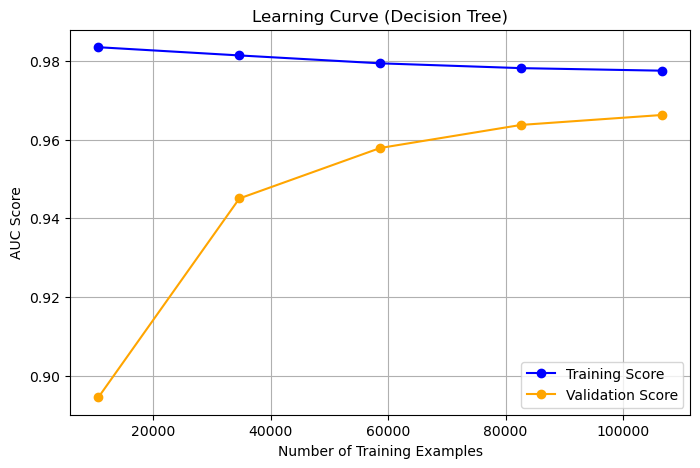



Evaluating Model: Random Forest
Best parameters for Random Forest: {'classifier__n_estimators': 100, 'classifier__min_samples_leaf': 5, 'classifier__max_depth': 7}
Classification Report untuk Random Forest:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     36016
           1       0.53      0.95      0.68      3984

    accuracy                           0.91     40000
   macro avg       0.76      0.93      0.81     40000
weighted avg       0.95      0.91      0.92     40000



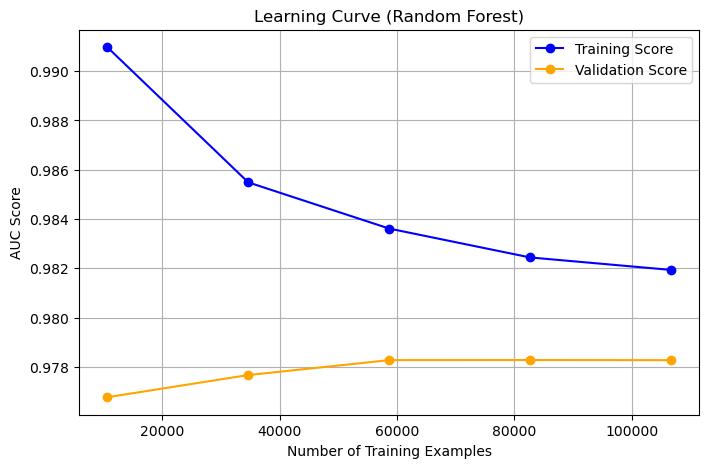



Evaluating Model: XGBoost
Best parameters for XGBoost: {'classifier__subsample': 0.8, 'classifier__n_estimators': 100, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.1}
Classification Report untuk XGBoost:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     36016
           1       0.63      0.96      0.76      3984

    accuracy                           0.94     40000
   macro avg       0.81      0.95      0.86     40000
weighted avg       0.96      0.94      0.94     40000



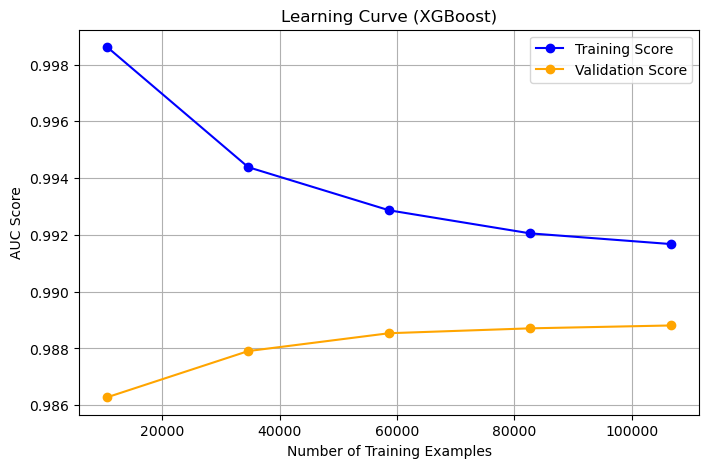



Evaluating Model: LightGBM
[LightGBM] [Info] Number of positive: 15937, number of negative: 144063
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021520 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12078
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 167
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

d:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       1.00      0.94      0.96     36016
           1       0.62      0.96      0.75      3984

    accuracy                           0.94     40000
   macro avg       0.81      0.95      0.86     40000
weighted avg       0.96      0.94      0.94     40000



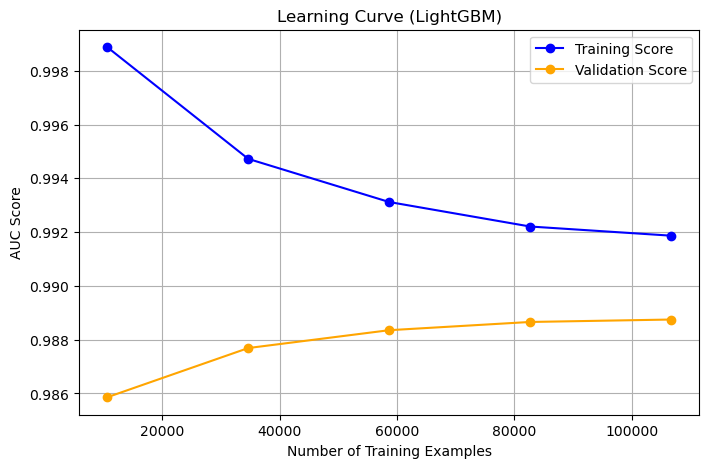

In [42]:
for name, settings in Models.items():
    print(f"Evaluating Model: {name}")
    
    main_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', settings['model'])
    ])
    
    random_search = RandomizedSearchCV(
        main_pipeline, 
        param_distributions=settings['params'], 
        n_iter=5, 
        cv=3, 
        scoring='roc_auc', 
        random_state=42,
        n_jobs=-1
    )
    
    random_search.fit(x_train, y_train)
    
    best_tuned_model = random_search.best_estimator_
    
    print(f"Best parameters for {name}:", random_search.best_params_)
    
    y_pred = best_tuned_model.predict(x_test)
    
    class_report(y_test, y_pred, name)
    
    plot_learning_curve(best_tuned_model, x_train, y_train, name)
    
    print("\n")

## Conclusions

Handling Imbalanced Data: Our target variable, battery_failure, was highly imbalanced. We successfully resolved this issue by applying the stratify technique during the train-test split and using class_weight (or scale_pos_weight) to penalize the model during training.

Evaluation Metric: We focused on the Recall metric for the minority class (Class 1). In our business case, predicting a healthy battery as a failure (a false alarm) is much safer than missing an actual battery failure. We must prioritize catching the worst-case scenario.

Model Health (No Overfitting): At first glance, the learning curves might look like they are overfitting. However, the actual gap between the training score and the validation score is extremely small. This confirms that our models are very healthy and not overfitting.

Final Model Selection: Among all the tested models, XGBoost and LightGBM provided the most outstanding results. XGBoost performed slightly better overall with a lower false alarm rate. Therefore, we selected and saved the XGBoost model as our final choice.

In [45]:
import joblib
model_xgb_best = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    scale_pos_weight= ratio,
    random_state=42,
    eval_metric='logloss'
)

pipe_xgboost_final = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model_xgb_best)
])

pipe_xgboost_final.fit(x_train, y_train)

joblib.dump(pipe_xgboost_final, 'model_xgboost_best.pkl')

print("Model XGBoost Saved! 'model_xgboost_best.pkl'!")

Model XGBoost Saved! 'model_xgboost_best.pkl'!
